In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/PostureDetection'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/dataset', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/runs', exist_ok=True)
print("✅ Drive mounted. Project folder ready.")

Mounted at /content/drive
✅ Drive mounted. Project folder ready.


In [4]:
!pip install roboflow ultralytics -q
print("✅ Packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 130.6 MB/s eta 0:00:00
✅ Packages installed.


In [5]:
import os
os.chdir(f'/content/drive/MyDrive/PostureDetection/dataset')

from roboflow import Roboflow
rf = Roboflow(api_key="MNISpB8zzvZ3nVEWSMJ9")
project = rf.workspace("min-bnvzi").project("sitting-posture-v2")
version = project.version(4)
dataset = version.download("yolov8")

print(f"✅ Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset downloaded to: /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4


In [6]:
import yaml

yaml_path = f'{dataset.location}/data.yaml'
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("Classes:", data['names'])
print("Number of classes:", data['nc'])
print("Train path:", data.get('train'))
print("Val path:", data.get('val'))

Classes: ['0', '1']
Number of classes: 2
Train path: ../train/images
Val path: ../valid/images


In [7]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
GPU name: Tesla T4


In [8]:
from ultralytics import YOLO
import os

model = YOLO('yolov8m.pt')

results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    name='posture_yolov8m',
    project=f'{PROJECT_DIR}/runs',
    device=0,
    patience=10,
    save=True,
    plots=True,
    verbose=True
)

print("✅ Training complete!")
print(f"Best model saved at: {PROJECT_DIR}/runs/posture_yolov8m/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha

KeyboardInterrupt: 

In [9]:
best_model_path = f'{PROJECT_DIR}/runs/posture_yolov8m/weights/best.pt'
model = YOLO(best_model_path)

metrics = model.val(data=yaml_path)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.p.mean())
print("Recall:", metrics.box.r.mean())

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 1.2±1.0 ms, read: 16.6±8.8 MB/s, size: 41.8 KB)
val: Scanning /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/valid/labels.cache... 191 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 191/191 38.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.3it/s 9.1s
                   all        191        201       0.93      0.932       0.97      0.686
                     0        101        101      0.932      0.955      0.982      0.722
                     1         99        100      0.928      0.909      0.958       0.65
Speed: 2.4ms preprocess, 21.6ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to /content/drive/MyDrive/PostureDetection/dataset/runs/detect/val-2
mAP50: 0.96


image 1/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-100-_jpg.rf.c770de56d7289cc7679b1a3dba7c9abe.jpg: 640x640 1 1, 36.9ms
image 2/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1000-_jpg.rf.66da427fd3349d7d6ff6509f316d9897.jpg: 640x640 1 0, 36.9ms
image 3/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1005-_jpg.rf.b46ae0dec5fe40366763e30b9c3a02ff.jpg: 640x640 1 0, 38.9ms
image 4/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1007-_jpg.rf.e8e30dbd9cf38cb27294c95b356922dc.jpg: 640x640 1 0, 1 1, 37.0ms
image 5/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1010-_jpg.rf.7d8c26a84faa929c599ad6d43b593cc1.jpg: 640x640 1 1, 37.0ms
image 6/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1011-_jpg.rf.4c2b34d8b35a6337877efe6cdcc

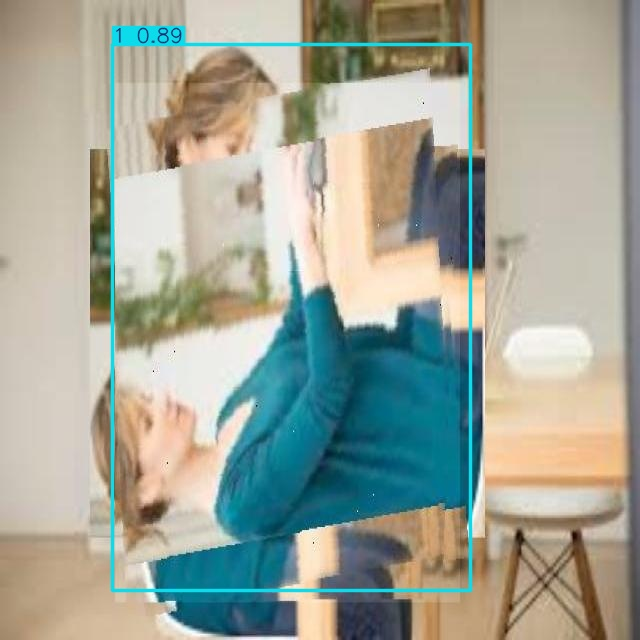

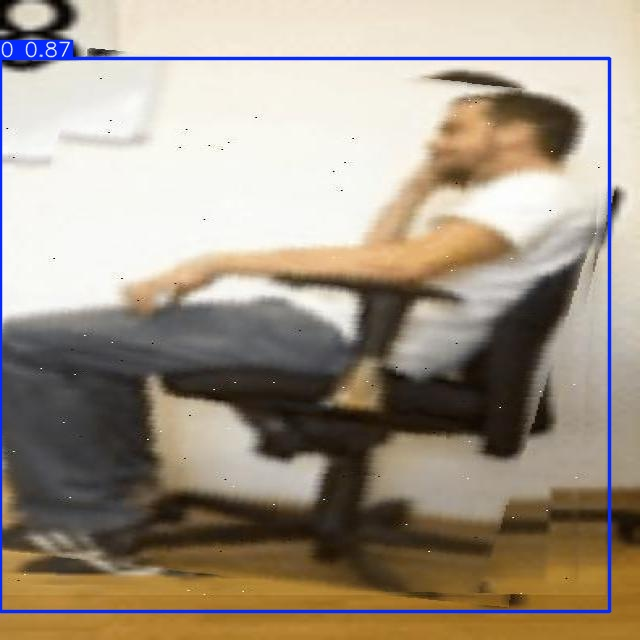

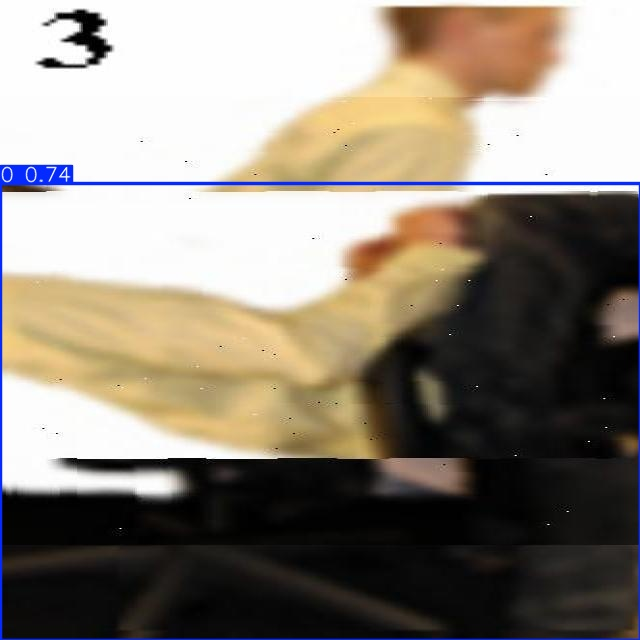

In [10]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

model = YOLO(best_model_path)

# Run on test set
results = model.predict(
    source=f'{dataset.location}/test/images',
    conf=0.4,
    save=True,
    project=f'{PROJECT_DIR}/test_results',
    name='images'
)

# Show first 3 results
output_imgs = glob.glob(f'{PROJECT_DIR}/test_results/images/*.jpg')[:3]
for img in output_imgs:
    display(Image(img))


image 1/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-100-_jpg.rf.c770de56d7289cc7679b1a3dba7c9abe.jpg: 640x640 1 1, 36.9ms
image 2/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1000-_jpg.rf.66da427fd3349d7d6ff6509f316d9897.jpg: 640x640 1 0, 33.6ms
image 3/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1005-_jpg.rf.b46ae0dec5fe40366763e30b9c3a02ff.jpg: 640x640 1 0, 30.4ms
image 4/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1007-_jpg.rf.e8e30dbd9cf38cb27294c95b356922dc.jpg: 640x640 1 0, 1 1, 30.4ms
image 5/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1010-_jpg.rf.7d8c26a84faa929c599ad6d43b593cc1.jpg: 640x640 1 1, 30.4ms
image 6/95 /content/drive/MyDrive/PostureDetection/dataset/Sitting-Posture-v2-4/test/images/posture-1011-_jpg.rf.4c2b34d8b35a6337877efe6cdcc

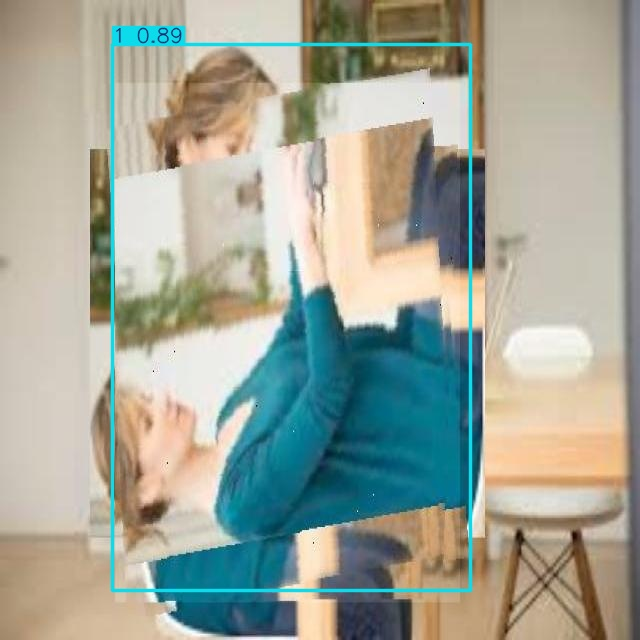

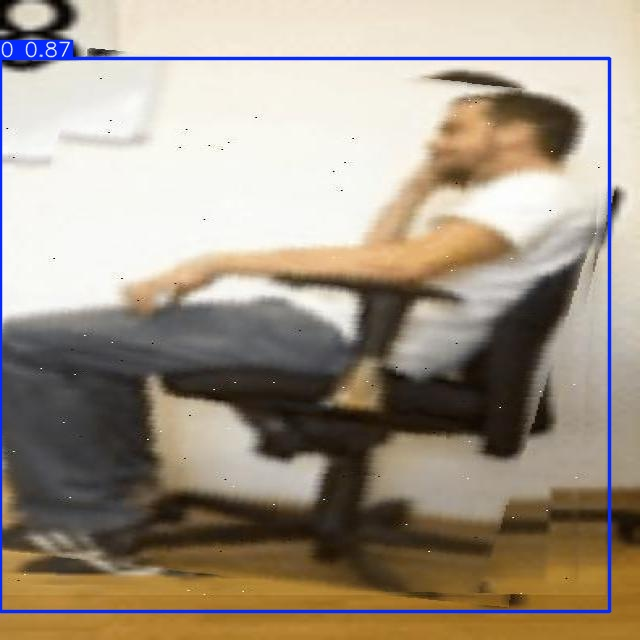

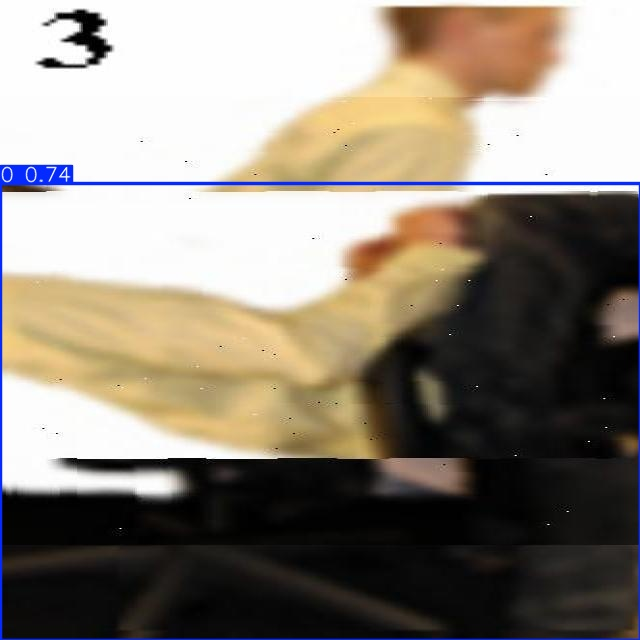

In [11]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob

model = YOLO(best_model_path)

# Run on test set
results = model.predict(
    source=f'{dataset.location}/test/images',
    conf=0.4,
    save=True,
    project=f'{PROJECT_DIR}/test_results',
    name='images'
)

# Show first 3 results
output_imgs = glob.glob(f'{PROJECT_DIR}/test_results/images/*.jpg')[:3]
for img in output_imgs:
    display(Image(img))